# USAspending Public Buildings Service EDA

This notebook examines GSA Public Buildings Service contract transactions.
FY2024 is the development period and FY2025 is reserved as a temporal holdout.
The analysis describes source behavior and data quality evidence without labeling naturally unusual records as defects.

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

from datalens.analysis.eda import duplicate_summary, join_quality, profile_table
from datalens.paths import PROJECT_ROOT

sns.set_theme(style="whitegrid")
DATA_DIR = PROJECT_ROOT / "data" / "processed"

transactions = {
    fiscal_year: pd.read_parquet(DATA_DIR / f"fy{fiscal_year}" / "transactions.parquet")
    for fiscal_year in ("2024", "2025")
}
vendors = {
    fiscal_year: pd.read_parquet(DATA_DIR / f"fy{fiscal_year}" / "vendors.parquet")
    for fiscal_year in ("2024", "2025")
}

## Shape, grain, and relationships

A transaction record is one USAspending contract action identified by `contract_transaction_unique_key`.
A vendor record is the latest observed representation of one recipient UEI, with DUNS retained only as a legacy fallback.
Each transaction belongs to exactly one derived vendor through `vendor_id`.

In [7]:
shape_rows = []
for fiscal_year in transactions:
    shape_rows.append(
        {
            "fiscal_year": fiscal_year,
            "transaction_rows": len(transactions[fiscal_year]),
            "transaction_columns": len(transactions[fiscal_year].columns),
            "vendor_rows": len(vendors[fiscal_year]),
            "vendor_columns": len(vendors[fiscal_year].columns),
        }
    )
display(pd.DataFrame(shape_rows))

for fiscal_year in transactions:
    print(
        f"FY{fiscal_year} transaction keys:",
        duplicate_summary(transactions[fiscal_year], key="contract_transaction_unique_key"),
    )
    print(f"FY{fiscal_year} vendor keys:", duplicate_summary(vendors[fiscal_year], key="vendor_id"))
    print(
        f"FY{fiscal_year} join quality:",
        join_quality(vendors[fiscal_year], transactions[fiscal_year]),
    )

,fiscal_year,transaction_rows,transaction_columns,vendor_rows,vendor_columns
0,2024,22064,78,1785,22
1,2025,19671,78,1652,22


FY2024 transaction keys: {'rows': 22064, 'exact_duplicate_rows': 0, 'duplicate_key_rows': 0, 'duplicate_key_values': 0, 'missing_key_rows': 0}
FY2024 vendor keys: {'rows': 1785, 'exact_duplicate_rows': 0, 'duplicate_key_rows': 0, 'duplicate_key_values': 0, 'missing_key_rows': 0}
FY2024 join quality: {'transaction_rows': 22064, 'vendor_rows': 1785, 'missing_vendor_key_rows': 0, 'unmatched_vendor_key_rows': 0, 'matched_transaction_rows': 22064, 'match_rate_percent': 100.0}
FY2025 transaction keys: {'rows': 19671, 'exact_duplicate_rows': 0, 'duplicate_key_rows': 0, 'duplicate_key_values': 0, 'missing_key_rows': 0}
FY2025 vendor keys: {'rows': 1652, 'exact_duplicate_rows': 0, 'duplicate_key_rows': 0, 'duplicate_key_values': 0, 'missing_key_rows': 0}
FY2025 join quality: {'transaction_rows': 19671, 'vendor_rows': 1652, 'missing_vendor_key_rows': 0, 'unmatched_vendor_key_rows': 0, 'matched_transaction_rows': 19671, 'match_rate_percent': 100.0}


## Field types and missingness

The profile distinguishes storage types from likely semantic types.
Missing values are interpreted in context because fields such as parent award, set-aside, and action type are not required for every action.

,field,dtype,semantic_type,missing_count,missing_percent,unique_count
0,recipient_duns,string,categorical,22064,100.000,0
1,recipient_parent_duns,string,categorical,22064,100.000,0
2,recipient_doing_business_as_name,string,categorical,21936,99.420,39
3,recipient_address_line_2,string,categorical,18750,84.980,169
4,type_of_set_aside,string,categorical,17071,77.370,11
5,type_of_set_aside_code,string,identifier,17071,77.370,11
6,number_of_offers_received,Int64,numeric,10256,46.483,38
7,action_type,string,categorical,8843,40.079,16
8,action_type_code,string,identifier,8843,40.079,16
9,solicitation_date,"datetime64[ns, UTC]",date,8137,36.879,1225


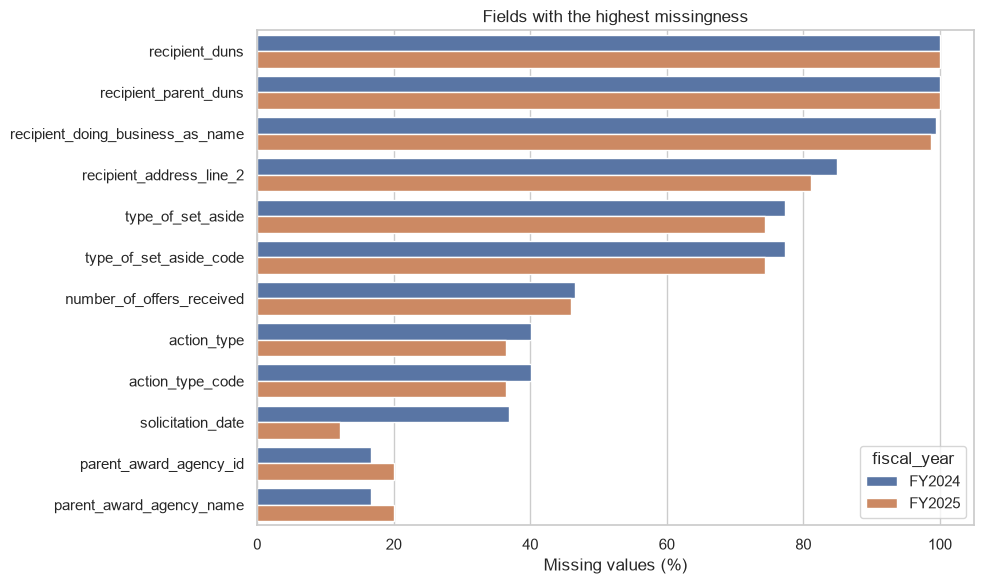

In [8]:
profiles = {fiscal_year: profile_table(frame) for fiscal_year, frame in transactions.items()}
display(profiles["2024"].head(20))

missing_comparison = (
    profiles["2024"][["field", "missing_percent"]]
    .rename(columns={"missing_percent": "FY2024"})
    .merge(
        profiles["2025"][["field", "missing_percent"]].rename(
            columns={"missing_percent": "FY2025"}
        ),
        on="field",
    )
)
missing_plot = (
    missing_comparison.assign(max_missing=lambda frame: frame[["FY2024", "FY2025"]].max(axis=1))
    .nlargest(12, "max_missing")
    .drop(columns="max_missing")
    .melt(id_vars="field", var_name="fiscal_year", value_name="missing_percent")
)

plt.figure(figsize=(10, 6))
sns.barplot(data=missing_plot, y="field", x="missing_percent", hue="fiscal_year")
plt.title("Fields with the highest missingness")
plt.xlabel("Missing values (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Numeric and categorical distributions

Federal action obligations include positive obligations, zero-dollar administrative actions, and negative deobligations.
A symmetric logarithmic scale preserves all three operationally valid regions.

,2024,2025
count,22064.0,19671.0
mean,180565.479563,180108.586715
std,4347782.469042,3277337.086117
min,-57432741.0,-38337514.0
1%,-73966.2112,-140110.432
5%,-3319.5715,-6382.58
25%,0.0,0.0
50%,6033.74,4488.41
75%,34409.97,27777.845
95%,449072.372,441274.195


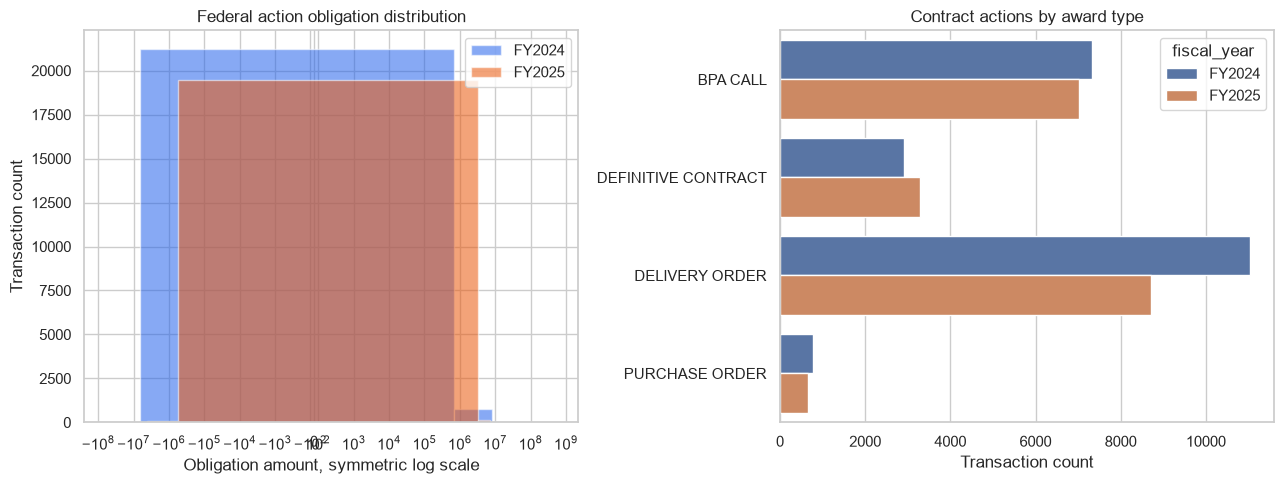

In [9]:
obligation_summary = pd.DataFrame(
    {
        fiscal_year: frame["federal_action_obligation"].describe(
            percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
        )
        for fiscal_year, frame in transactions.items()
    }
)
display(obligation_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for fiscal_year, color in (("2024", "#2563eb"), ("2025", "#ea580c")):
    axes[0].hist(
        transactions[fiscal_year]["federal_action_obligation"],
        bins=80,
        alpha=0.55,
        label=f"FY{fiscal_year}",
        color=color,
    )
axes[0].set_xscale("symlog", linthresh=1_000)
axes[0].set_title("Federal action obligation distribution")
axes[0].set_xlabel("Obligation amount, symmetric log scale")
axes[0].set_ylabel("Transaction count")
axes[0].legend()

award_types = (
    pd.concat(
        [
            frame.assign(fiscal_year=f"FY{fiscal_year}")
            for fiscal_year, frame in transactions.items()
        ],
        ignore_index=True,
    )
    .groupby(["fiscal_year", "award_type"], observed=True)
    .size()
    .rename("transactions")
    .reset_index()
)
sns.barplot(data=award_types, y="award_type", x="transactions", hue="fiscal_year", ax=axes[1])
axes[1].set_title("Contract actions by award type")
axes[1].set_xlabel("Transaction count")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

## Vendor concentration and temporal behavior

Vendor activity is strongly concentrated, so record-level evaluation alone could overstate performance on high-volume recipients.
Monthly volume also changes through the fiscal year, which supports preserving FY2025 as a genuine temporal holdout.

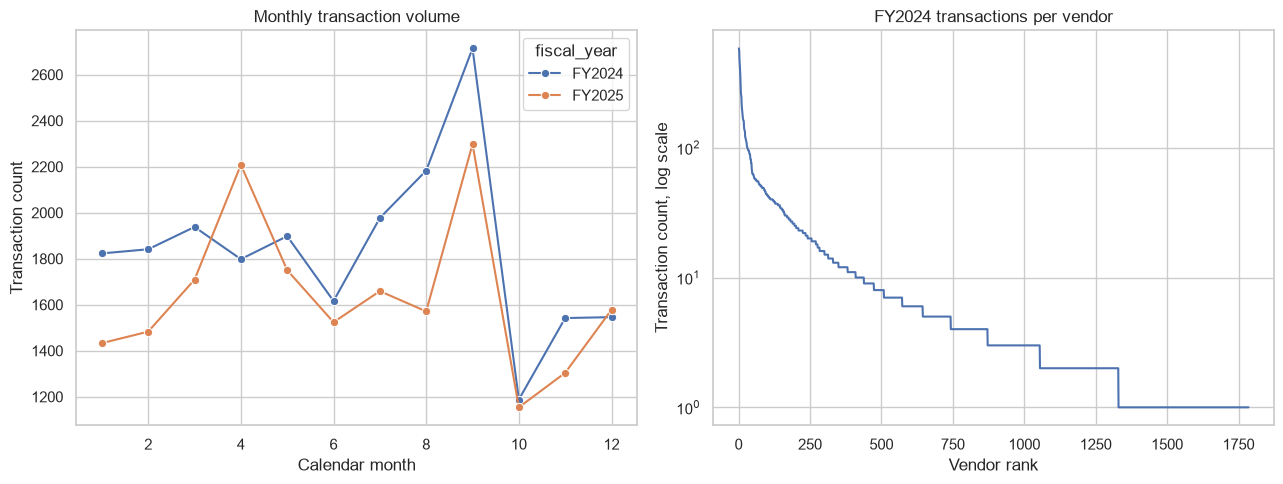

0.00      1.00
0.50      3.00
0.90     28.00
0.95     47.00
0.99    147.56
1.00    582.00
Name: source_transaction_count, dtype: float64

In [10]:
combined = pd.concat(
    [frame.assign(fiscal_year=f"FY{fiscal_year}") for fiscal_year, frame in transactions.items()],
    ignore_index=True,
)
combined["fiscal_month"] = combined["action_date"].dt.month
monthly = (
    combined.groupby(["fiscal_year", "fiscal_month"], observed=True)
    .size()
    .rename("transactions")
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.lineplot(
    data=monthly,
    x="fiscal_month",
    y="transactions",
    hue="fiscal_year",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Monthly transaction volume")
axes[0].set_xlabel("Calendar month")
axes[0].set_ylabel("Transaction count")

vendor_volume = vendors["2024"]["source_transaction_count"].sort_values(ascending=False)
axes[1].plot(range(1, len(vendor_volume) + 1), vendor_volume.to_numpy())
axes[1].set_yscale("log")
axes[1].set_title("FY2024 transactions per vendor")
axes[1].set_xlabel("Vendor rank")
axes[1].set_ylabel("Transaction count, log scale")
plt.tight_layout()
plt.show()

display(vendors["2024"]["source_transaction_count"].quantile([0, 0.5, 0.9, 0.95, 0.99, 1]))

## Candidate quality checks and limitations

- Transaction keys and derived vendor keys are unique in both periods.
- Every transaction joins to a vendor through UEI in the downloaded extracts.
- DUNS is entirely absent, which is expected after the federal transition to UEI and should not be treated as a defect.
- Negative obligations are valid deobligations and zero-dollar actions are often administrative, so sign alone is not a defect rule.
- Parent award fields are structurally absent for standalone awards.
- Action type and offer count missingness depend on action and competition context.
- One record in each fiscal year has a current performance end date before its performance start date and merits review, but source unusualness is not ground truth.
- Vendor addresses vary across transactions for hundreds of vendors, which could reflect correction, relocation, formatting, or genuine inconsistency.
- FY2024 and FY2025 cover one GSA sub-agency and do not represent all federal procurement or private-enterprise vendor master data.
- The API extract reflects USAspending as updated on the acquisition date, so later reruns may contain source corrections.

Open questions for controlled-defect design are whether missingness should be conditional on award context, which date relationships are universally invalid, and how vendor address consistency should distinguish movement from contradictory simultaneous values.